<a href="https://colab.research.google.com/github/ddoneu/FinalProject-Employee-Attrition-Prediction/blob/main/Checkpoint%201/Final_Project_Dat_Do.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1st Checkpoint - April 19

## **PART 1: PROPOSAL**

1. **Prediction question:** Can we predict whether an employee will voluntarily leave the organization based on their demographic, compensation, and job-satisfaction characteristics?

2. **Prediction vs. causation:** This is a prediction task, not causal inference. Feature importance scores reflect predictive associations, not causal effects. For example, if "OverTime" is a strong predictor, that doesn't mean eliminating overtime would necessarily reduce attrition.

3. **Dataset:** IBM HR Analytics Employee Attrition Dataset from Kaggle (https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset), N = 1,470 employees, 35 features, binary target Attrition (Yes/No).

4. **Stakeholder:** An HR director at a mid-size firm deciding which employee segments to target with retention programs (flexible scheduling, compensation adjustments, career development), prioritizing segments where predicted attrition risk is highest and intervention cost is lowest.



## **PART 2: Exploratory Data Analysis**

In [12]:
#Set up environment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve)

In [13]:
#Load data from Kaggle

!pip install -q kagglehub

import kagglehub
import pandas as pd

path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
df = pd.read_csv(path + "/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")


#Describe the Data (shape, dtypes)
print("DATA TYPES:")
for dtype, count in df.dtypes.value_counts().items():
    print(f"  {dtype}: {count} columns")

df.describe().round(2)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Dataset shape: 1,470 rows × 35 columns

DATA TYPES:
  int64: 26 columns
  object: 9 columns


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [14]:
# Missing data check (MCAR/MAR/MNAR Framework)
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': missing_pct
})

if missing_counts.sum() == 0:
    print("Dataset completeness: 100%")
    print()
    print("-> No missing values detected.")
    print("-> MCAR/MAR/MNAR classification is not applicable because there is no observed missingness.")
    print("-> No imputation strategy is needed.")
else:
    print(missing_summary[missing_summary['missing_count'] > 0])

print(f"\nTotal missing values: {missing_counts.sum()}")

Dataset completeness: 100%

-> No missing values detected.
-> MCAR/MAR/MNAR classification is not applicable because there is no observed missingness.
-> No imputation strategy is needed.

Total missing values: 0


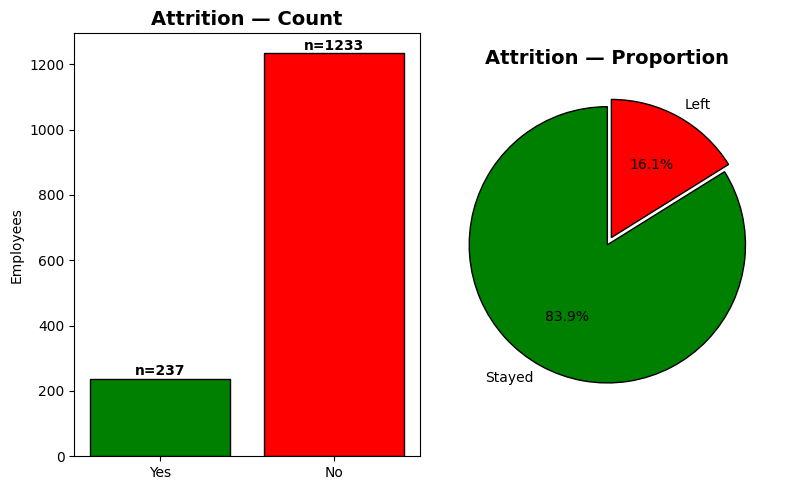

Attrition rate: 16.1%
Class imbalance present — will prioritize recall & F1 over accuracy.


In [15]:
#Visual 1: Attrition Distribution:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# Bar chart
counts = df['Attrition'].value_counts().reindex(['Yes', 'No'])
colors = ['green', 'red']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Attrition — Count', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Employees')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 12,
                f'n={val}', ha='center', fontweight='bold')

# Pie chart
pct = df['Attrition'].value_counts(normalize=True) * 100
axes[1].pie(pct.values, labels=['Stayed', 'Left'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.06),
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Attrition — Proportion', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Attrition rate: {pct['Yes']:.1f}%")
print("Class imbalance present — will prioritize recall & F1 over accuracy.")

**Interpretation**: About 16% of employees left while roughly 84% stayed, so the target variable is clearly imbalanced. This means a naive model that predicts “Stayed” for everyone would appear accurate but would fail to identify actual leavers. As a result, recall and F1-score will be more informative than accuracy when evaluating attrition models.


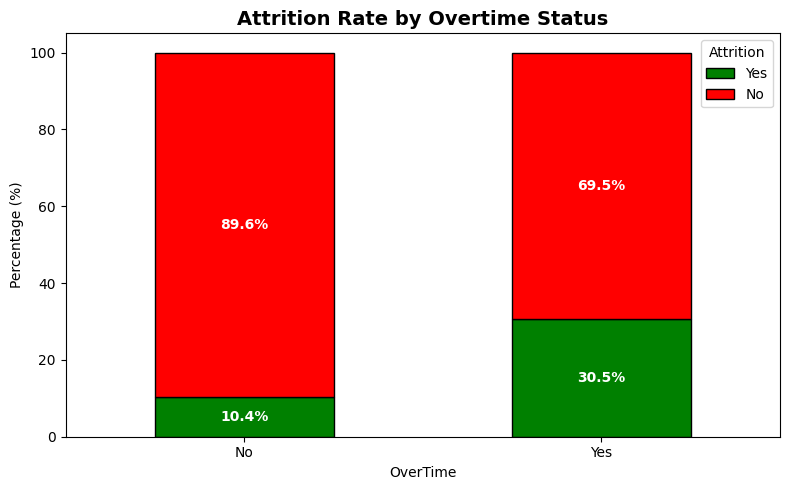

In [16]:
#Attrition by Overtime

fig, ax = plt.subplots(figsize=(8, 5))

ct = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
ct[['Yes', 'No']].plot(kind='bar', stacked=True, color=['green', 'red'],edgecolor='black', ax=ax)
ax.set_title('Attrition Rate by Overtime Status', fontweight='bold', fontsize=14)
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Attrition')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center',fontweight='bold', color='white')

plt.tight_layout()
plt.show()

**Interpretation**: Employees who work overtime have an attrition rate of 30.5%, compared with only 10.4% for those who do not. This suggests that Overtime is likely one of the strongest predictive features in the dataset. However, this should be interpreted as a predictive association rather than evidence that overtime itself causes attrition.

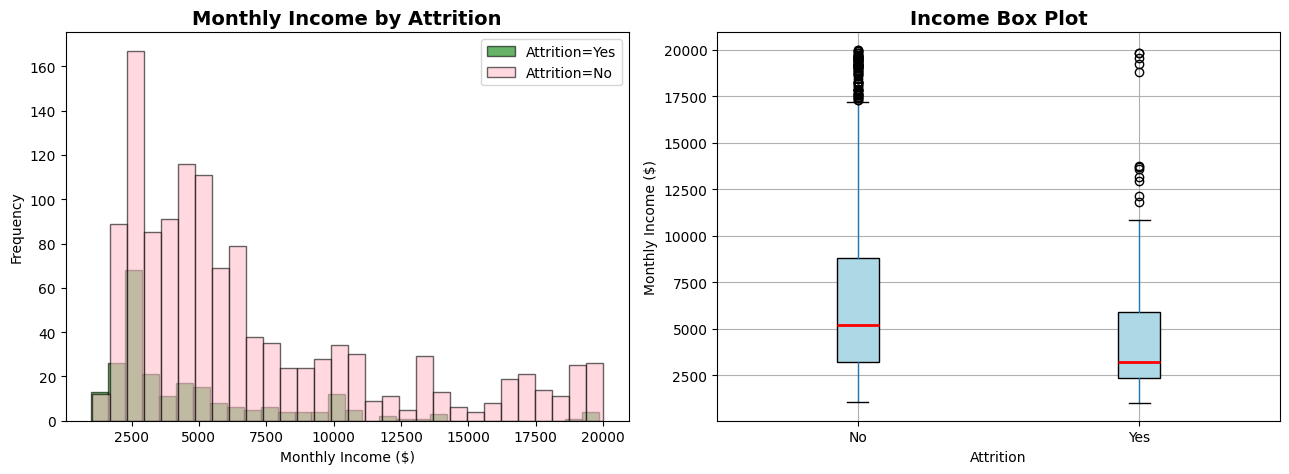


            count    mean     std     min     25%     50%     75%      max
Attrition                                                                 
No         1233.0  6833.0  4818.0  1051.0  3211.0  5204.0  8834.0  19999.0
Yes         237.0  4787.0  3640.0  1009.0  2373.0  3202.0  5916.0  19859.0


In [17]:
#Visualization 3: Monthly income by attrition
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
for label, color in zip(['Yes', 'No'], ['green', 'pink']):
    axes[0].hist(df[df['Attrition']==label]['MonthlyIncome'], bins=30, alpha=0.6, label=f'Attrition={label}', color=color, edgecolor='black')
axes[0].set_title('Monthly Income by Attrition', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Monthly Income ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
df.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[1], patch_artist=True, boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Income Box Plot', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Monthly Income ($)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print()
print('=='*40)

print(df.groupby('Attrition')['MonthlyIncome'].describe().round(0))

**Interpretation:** Employees who left the company have a lower median monthly income than those who stayed. The histogram suggests that attrition cases are more concentrated in the lower-income range, and the box plot confirms a noticeable gap in medians between the two groups. This implies that compensation is likely a useful predictive feature for attrition, although this pattern should be interpreted as association rather than causal evidence.

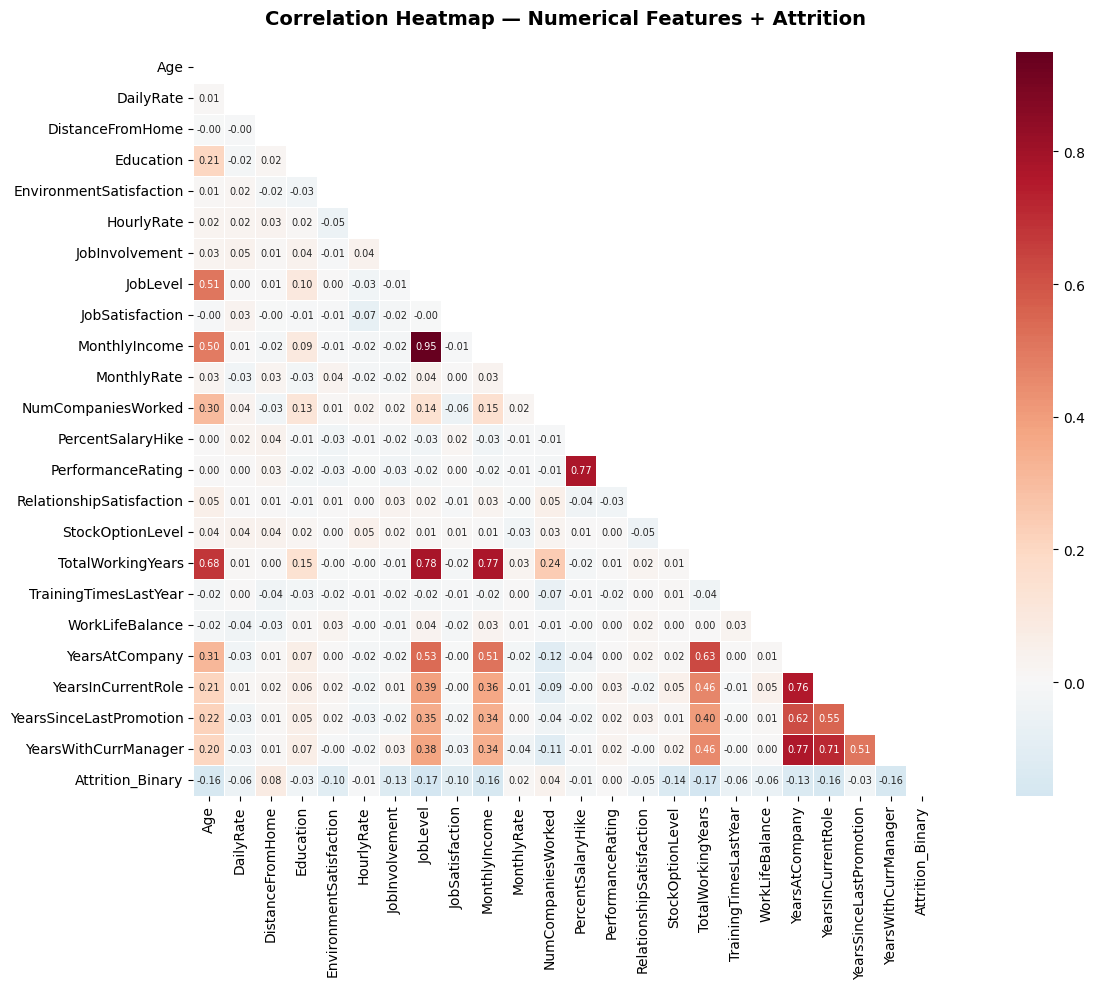


Top 10 features correlated with Attrition (|r|):
   1. TotalWorkingYears              0.171
   2. JobLevel                       0.169
   3. YearsInCurrentRole             0.161
   4. MonthlyIncome                  0.160
   5. Age                            0.159
   6. YearsWithCurrManager           0.156
   7. StockOptionLevel               0.137
   8. YearsAtCompany                 0.134
   9. JobInvolvement                 0.130
  10. JobSatisfaction                0.103


In [18]:
#Visualization 4: Correlation heatmap
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
            if c not in ['EmployeeCount', 'StandardHours', 'EmployeeNumber']]
df_corr = df[num_cols].copy()
df_corr['Attrition_Binary'] = (df['Attrition'] == 'Yes').astype(int)
corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(16, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap — Numerical Features + Attrition',
             fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\nTop 10 features correlated with Attrition (|r|):")
top = corr['Attrition_Binary'].drop('Attrition_Binary').abs().sort_values(ascending=False)
for i, (feat, val) in enumerate(top.head(10).items(), 1):
    print(f"  {i:2d}. {feat:<30s} {val:.3f}")

**Interpretation:** The horizontal bar chart ranks the top 10 numerical features by their absolute correlation with attrition. TotalWorkingYears, JobLevel, and YearsInCurrentRole show the strongest linear associations, followed by MonthlyIncome and Age. This suggests a consistent pattern: employees who are younger, lower-paid, and earlier in their careers are more likely to leave. The clustering of tenure-related variables such as YearsAtCompany, YearsWithCurrManager, and YearsInCurrentRole also suggests that organizational attachment and career stage are important predictive signals for retention.

### Data Quality Summary:

The dataset is relatively clean and suitable for predictive modeling. It contains 1,470 employee records and the target variable, Attrition, is clearly defined as a binary outcome.

I checked for missing values and found no observed missingness, so no imputation or row deletion was required. This reduces the risk of bias from missing-data handling and allows the full sample to be retained.

The main data-quality concern is class imbalance: only about 16% of employees left, while about 84% stayed. This means model evaluation should prioritize recall, precision, and F1-score rather than relying only on accuracy. The EDA also suggests that attrition is associated with several employee characteristics, including overtime status, monthly income, age, and tenure-related variables, so the prediction task likely depends on combining multiple signals rather than one dominant feature. Overall, the dataset appears complete, structured, and appropriate for a binary classification project.

#PART 3: PRELIMINARY MODEL

In [19]:
# Drop constant & noninformative columns
drop_cols = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df_model = df.drop(columns=drop_cols).copy()

# Encode target: Yes → 1, No → 0
df_model['Attrition'] = (df_model['Attrition'] == 'Yes').astype(int)

# One-hot encode categorical features
cat_cols = df_model.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print(f"Features after encoding: {df_encoded.shape[1] - 1}")

Features after encoding: 44


In [20]:
#Train/Test Split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples | Attrition rate: {y_train.mean():.1%}")
print(f"Test set:     {X_test.shape[0]} samples | Attrition rate: {y_test.mean():.1%}")

Training set: 1176 samples | Attrition rate: 16.2%
Test set:     294 samples | Attrition rate: 16.0%


In [21]:
#Logistic Regression Baseline
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92       247
        Left       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294

Accuracy:  0.8605
Precision: 0.6154
Recall:    0.3404
F1 Score:  0.4384


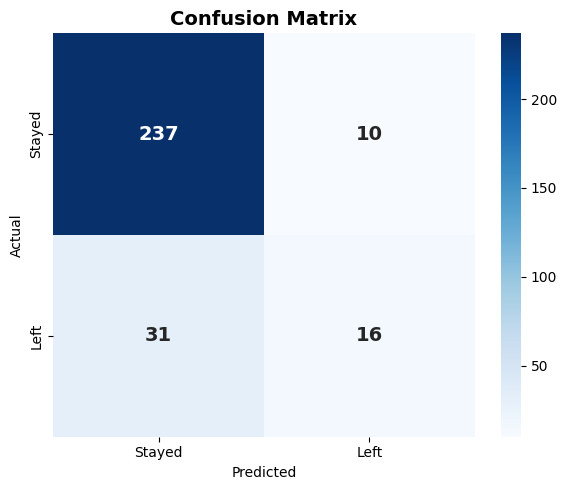

In [22]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'], ax=ax, annot_kws={'size': 14, 'fontweight': 'bold'})
ax.set_title('Confusion Matrix', fontweight='bold', fontsize=14)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

**Preliminary Model Summary:**

As an initial benchmark, I fit a logistic regression model using an 80/20 train-test split with random_state=42 and stratify=y to preserve the attrition rate in both samples. Because logistic regression is simple, interpretable, and widely used for binary classification, it serves as a useful baseline before moving to more flexible machine learning models. I standardized the predictors with StandardScaler so the model could estimate coefficients on a comparable scale and converge more reliably.

A key challenge in this dataset is class imbalance: only about 16% of employees left, while roughly 84% stayed. This means accuracy alone is not an adequate performance measure, since a naïve classifier that predicts “Stayed” for every employee would already achieve around 84% accuracy while completely failing to identify actual leavers. For this reason, I place more weight on recall and F1-score for the “Left” class, because the practical goal is to flag employees who are at risk of attrition rather than simply maximize overall correctness on the majority class.

The confusion matrix and classification report provide a clearer picture of model performance by showing not only how often the model is correct, but also whether it is missing too many true attrition cases. This is especially important in an HR setting, where false negatives may be costly because they represent employees the firm fails to identify as retention risks. Overall, this logistic regression serves as a reasonable baseline model for the checkpoint, but it is not intended to be the final modeling choice.

In the final submission, I will extend the analysis by comparing this baseline against at least one tree-based model such as Random Forest or Gradient Boosting, which may capture nonlinear relationships and interactions more effectively. I also plan to include cross-validation for more stable model comparison and report confidence intervals or uncertainty bounds so that the final recommendation is transparent about predictive uncertainty.



**Disclaimer:** I did not use AI for this first checkpoint since it is mostly what we have done in all the Labs.